# Анализ системы метрик приложения

Задачи:
- провести анализ юнит-экономики продукта в динамике за первые 28 дней;
- разобраться в причинах стагнации выручки;
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости;
- дать рекомендации отделу маркетинга.


### Данные

Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_visits = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_visits.csv', parse_dates=['session_start','session_end'])
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_orders.csv', parse_dates=['event_dt'])
df_costs = pd.read_csv('https://code.s3.yandex.net/datasets/ppro_costs.csv', parse_dates=['dt'])

In [3]:
df_visits.head()

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00


In [4]:
df_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   region         161865 non-null  object        
 2   device         161865 non-null  object        
 3   channel        161865 non-null  object        
 4   session_start  161865 non-null  datetime64[ns]
 5   session_end    161865 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 7.4+ MB


In [5]:
duplicates_visits = df_visits.duplicated(keep = False).sum()
if duplicates_visits > 0:
    print(f'Кол-во дублей: {duplicates_visits}')
else:
    print('Дублей нет')

Дублей нет


В датафрейме `df_visits` пропусков и дублей нет, типы данных корректны.

In [6]:
display(df_orders.head())

,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99


In [7]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   33893 non-null  int64         
 1   event_dt  33893 non-null  datetime64[ns]
 2   revenue   33893 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 794.5 KB


In [8]:
duplicates_orders = df_orders.duplicated(keep = False).sum()
if duplicates_orders > 0:
    print(f'Кол-во дублей: {duplicates_orders}')
else:
    print('Дублей нет')

Дублей нет


Датафрейм `df_orders` тоже хорошего качества.

In [9]:
display(df_costs.head())

,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760


In [10]:
df_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       976 non-null    datetime64[ns]
 1   channel  976 non-null    object        
 2   costs    976 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 23.0+ KB


In [11]:
duplicates_costs = df_costs.duplicated(keep = False).sum()
if duplicates_costs > 0:
    print(f'Кол-во дублей: {duplicates_costs}')
else:
    print('Дублей нет')

Дублей нет


И с `df_costs` тоже всё хорошо.

In [12]:
if set(df_visits['channel']) == set(df_costs['channel']):
    print('источники привлечения  одинаковы в df_visit и df_costs')
else:
    print('Есть отличия')

источники привлечения  одинаковы в df_visit и df_costs


In [13]:
# Проверим пересечение данных, чтобы источники привлечения были одинаковы в df_visit и df_costs

print(f"Канал привлечения из df_visits: {sorted(df_visits['channel'].unique())}")
print()
print(f"Канал привлечения из df_costs: {sorted(df_costs['channel'].unique())}")

Канал привлечения из df_visits: ['FaceBoom', 'MediaTornado', 'RocketSuperAds', 'TipTop']

Канал привлечения из df_costs: ['FaceBoom', 'MediaTornado', 'RocketSuperAds', 'TipTop']


In [14]:
user_visits = set(df_visits['user_id'])
users_orders = set(df_orders['user_id'])

if user_visits >= users_orders:
    print('Все пользователи, которые совершили покупки, есть в таблице с событиями')
else:
    print('Есть расхождения!')

Все пользователи, которые совершили покупки, есть в таблице с событиями


**Итог:**  данные хорошего качества, можно продолжать работу дальше

## Подготовка данных к когортному анализу

Подготовлю данные к когортному анализу с учётом того, что буду изучать окупаемость привлечения пользователей за первые 28 дней.

Для каждого пользователя найду:
- дату первой сессии (дата привлечения пользователя, `first_dt`);
- канал привлечения (`first_channel`);
- стоимость привлечения пользователя (`cac`).

In [15]:
# Находим для каждого пользователя дату первой сессии и первый канал привлечения
profiles = df_visits.sort_values(by = 'session_start')
profiles = profiles.groupby('user_id').agg(
    first_dt = ('session_start', 'min'),
    first_channel = ('channel', 'first')).reset_index()

profiles['first_dt'] = profiles['first_dt'].dt.normalize()

# найдем кол-во пользователей для каждого канала и даты
nunique_users = profiles.groupby(['first_dt', 'first_channel'])['user_id'].nunique().reset_index()
nunique_users = nunique_users.rename(columns = {'user_id': 'cnt_users'})

# добавим к profiles, кол-во уникальных пользователей
profiles = profiles.merge(nunique_users, how = 'left', on = ['first_dt', 'first_channel'])

# считаем CAC
cac = df_costs.groupby(['dt', 'channel'])['costs'].sum().reset_index()

#объеденим CAC и profiles
profiles = profiles.merge(cac, how = 'left', left_on = ['first_dt', 'first_channel'], right_on = ['dt', 'channel'])

profiles['cac'] = profiles['costs'] / profiles['cnt_users']

profiles = profiles[['user_id', 'first_dt', 'first_channel', 'cac']]
profiles.head()

,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21,FaceBoom,1.208981


In [16]:
# объединение таблиц, чтобы найти лайфтайм
df_visits = df_visits.merge(profiles[['user_id', 'first_dt', 'first_channel']], how = 'left', on ='user_id')
df_visits.head()

,user_id,region,device,channel,session_start,session_end,first_dt,first_channel
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00,2024-04-01,MediaTornado
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00,2024-04-01,RocketSuperAds
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00,2024-04-01,MediaTornado
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00,2024-04-01,MediaTornado
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00,2024-04-01,RocketSuperAds


In [17]:
# находим лайфтайм / n_period
df_visits['n_period'] = df_visits['session_start'].dt.to_period('D').astype('int64') - df_visits['first_dt'].dt.to_period('D').astype('int64')
df_visits['session_start'] = df_visits['session_start'].dt.normalize()
df_visits.head()

,user_id,region,device,channel,session_start,session_end,first_dt,first_channel,n_period
0,631105188566,India,desktop,MediaTornado,2024-04-01,2024-04-01 04:19:00,2024-04-01,MediaTornado,0
1,892885906464,India,tv,RocketSuperAds,2024-04-01,2024-04-01 01:14:00,2024-04-01,RocketSuperAds,0
2,517003690029,India,mobile,MediaTornado,2024-04-01,2024-04-01 17:53:00,2024-04-01,MediaTornado,0
3,185156659289,India,mobile,MediaTornado,2024-04-01,2024-04-01 14:51:00,2024-04-01,MediaTornado,0
4,409503040345,India,mobile,RocketSuperAds,2024-04-01,2024-04-01 08:45:00,2024-04-01,RocketSuperAds,0


In [18]:
# df_visits[df_visits['user_id'] == 409503040345]
# df_visits.duplicated(keep = False).sum()

In [19]:
# объединение таблиц, чтобы почситать лайфтайм и добавить САС
df_orders = df_orders.merge(profiles, how = 'left', on = 'user_id')
df_orders['event_dt'] = pd.to_datetime(df_orders['event_dt']).dt.normalize()


In [20]:
df_orders['n_period'] = df_orders['event_dt'].dt.to_period('D').astype('int64') - df_orders['first_dt'].dt.to_period('D').astype('int64')
df_orders.head()

,user_id,event_dt,revenue,first_dt,first_channel,cac,n_period
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0.939390,0
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0.742467,0
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0


Датафрейм `profiles` сформирован, в него входят:

* ID пользователя;
* дата привлечения;
* первый канал привлечения;
* CAC на пользователя.

В `df_visits` добавили `first_dt` и `first_channel`, эти столбики пригодятся для дальнейшего анализа.

В `df_orders` также добавили эти столбцы, плюс еще `cac`.

Для `df_visits` и `df_orders` рассчитали дневной лайфтайм.

## Анализ месячной динамики основных метрик продукта

Начнем анализ данных с изучения динамики активности пользователей и их вовлеченности в продукт. рассчитаем DAU, MAU и Stickiness и визуализируем их. 

В разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC).
- Значение LTV и ROI с учётом покупок, совершённых за 28 дней с момента привлечения.


In [21]:
# df_visits.head(15)

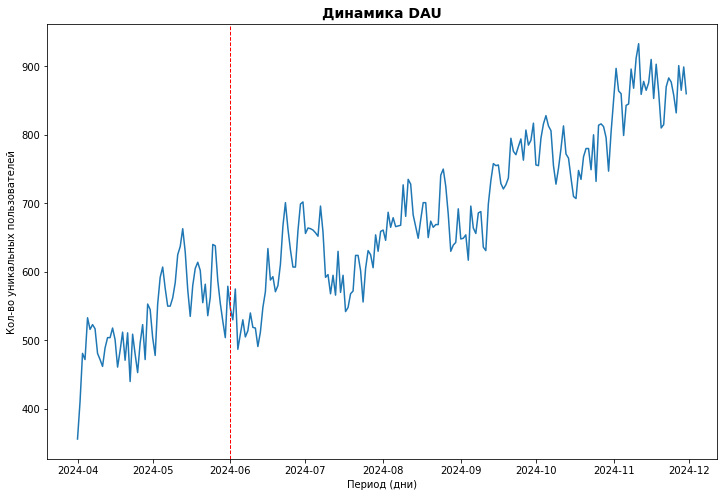

In [22]:
# DAU
df_dau = df_visits.groupby('session_start')['user_id'].nunique().reset_index()

plt.figure(figsize = (12, 8))
plt.plot(df_dau['session_start'], df_dau['user_id'])

plt.title('Динамика DAU', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (дни)')
plt.ylabel('Кол-во уникальных пользователей')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.show()

In [23]:
# df_dau

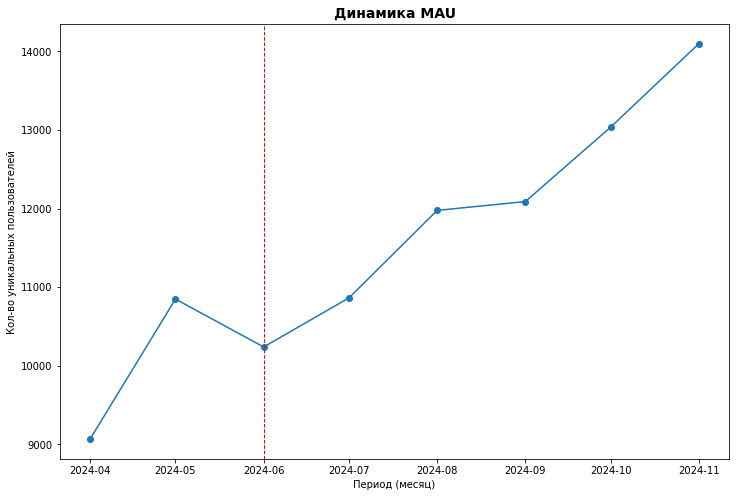

In [24]:
# MAU
df_mau = df_visits
df_mau['month'] = df_visits['session_start'].dt.to_period('M').dt.to_timestamp()

df_mau = df_mau.groupby('month')['user_id'].nunique().reset_index()

plt.figure(figsize = (12, 8))
plt.plot(df_mau['month'], df_mau['user_id'], marker = 'o')

plt.title('Динамика MAU', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (месяц)')
plt.ylabel('Кол-во уникальных пользователей')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.show()

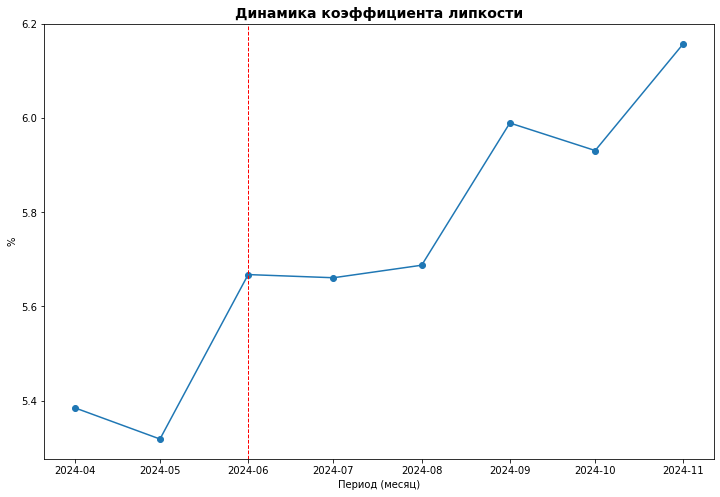

In [25]:
# Stickinees ratio

df_dau['month'] = df_dau['session_start'].dt.to_period('M').dt.to_timestamp()
df_dau = df_dau.rename(columns = {'user_id':'dau'})

df_dau_mean = df_dau.groupby('month')['dau'].mean().reset_index()
df_dau_mean = df_dau_mean.rename(columns = {'dau':'dau_mean'})

df_stickiness = df_mau.merge(df_dau_mean, on = 'month', how = 'left')
df_stickiness = df_stickiness.rename(columns = {'user_id':'mau'})

df_stickiness['stickiness'] = df_stickiness['dau_mean'] / df_stickiness['mau'] * 100
#df_stickiness

plt.figure(figsize = (12, 8))

plt.plot(df_stickiness['month'], df_stickiness['stickiness'], marker = 'o')

plt.title('Динамика коэффициента липкости', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (месяц)')
plt.ylabel('%')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.show()

Проанализировав `DAU`, `MAU` и `Stickiness`, можно сделать вывод, что количество активных пользователей растет и они стали чаще возвращаться в приложение, чем это было до внедрения нового вида контента (2024-06 — период внедрения нового вида контента).

In [26]:
profiles.head()

,user_id,first_dt,first_channel,cac
0,26034876,2024-05-29,FaceBoom,0.953250
1,69890364,2024-06-28,RocketSuperAds,0.604917
2,75610104,2024-06-09,FaceBoom,1.196159
3,76692397,2024-10-21,FaceBoom,1.147967
4,80224421,2024-06-21,FaceBoom,1.208981


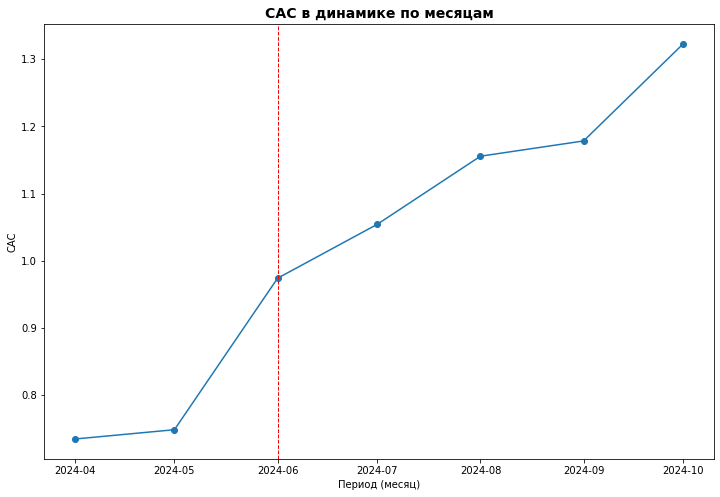

In [27]:
# CAC
cac = profiles
cac['month'] = cac ['first_dt'].dt.to_period('M').dt.to_timestamp()

cac = cac[cac['month'] < '2024-11-01']

cac = cac.groupby('month').agg(total_users = ('user_id', 'nunique'),
                                     cac = ('cac', 'mean')).reset_index()

plt.figure(figsize = (12, 8))

plt.plot(cac['month'], cac['cac'], marker = 'o')

plt.title('CAC в динамике по месяцам', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (месяц)')
plt.ylabel('CAC')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.show()

In [28]:
# расчитываем LTV и ROI

ltv = df_orders[df_orders['n_period'] < 28].copy()

ltv['month'] = ltv['first_dt'].dt.to_period('M').dt.to_timestamp()

ltv= ltv.groupby('month')['revenue'].sum().reset_index()
ltv = ltv.merge(cac, on = 'month')

ltv['ltv_28'] = ltv['revenue'] / ltv['total_users']

ltv['roi_28'] = (ltv['ltv_28'] - ltv['cac']) / ltv['cac'] * 100


ltv

,month,revenue,total_users,cac,ltv_28,roi_28
0,2024-04-01,7425.63,9069,0.734706,0.818793,11.444870
1,2024-05-01,8141.76,9789,0.748572,0.831725,11.108209
2,2024-06-01,7447.84,8719,0.973978,0.854208,-12.297015
3,2024-07-01,9991.41,8742,1.054344,1.142920,8.401051
4,2024-08-01,10367.05,9518,1.155601,1.089205,-5.745639
5,2024-09-01,10085.88,9198,1.178301,1.096530,-6.939783
6,2024-10-01,11449.71,9520,1.323047,1.202701,-9.096121


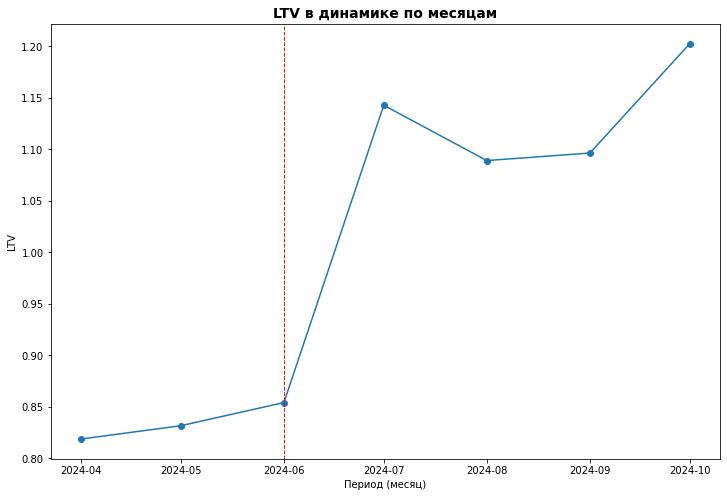

In [29]:
# визуальзация LTV

plt.figure(figsize = (12, 8))

plt.plot(ltv['month'], ltv['ltv_28'], marker = 'o')

plt.title('LTV в динамике по месяцам', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (месяц)')
plt.ylabel('LTV')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.show()

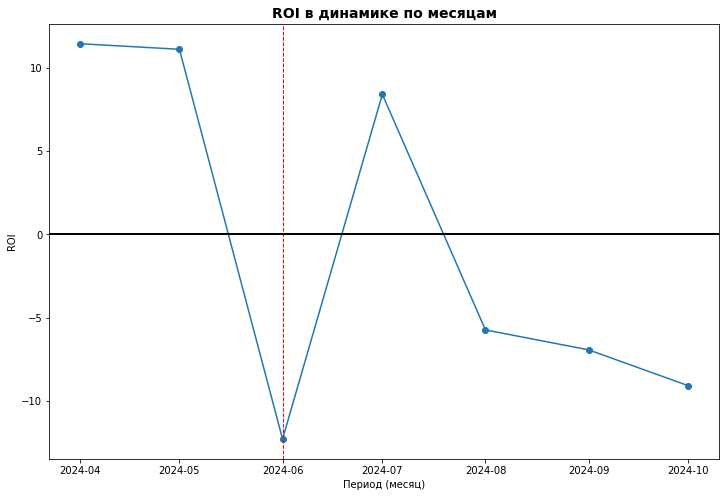

In [30]:
# визуальзация ROI

plt.figure(figsize = (12, 8))

plt.plot(ltv['month'], ltv['roi_28'], marker = 'o')

plt.title('ROI в динамике по месяцам', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (месяц)')
plt.ylabel('ROI')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.axhline (0,
            color = 'black',
            linestyle = '-',
            linewidth = 2)

plt.show()

In [31]:
# df_ROI

`CAC` сильно вырос после появления нового контента. Если сравнивать с «периодами до» (апрель - май) Это логичное поведение метри с учетом того, что появилось новое направление. 

`LTV` начинает расти после 2024-06, что может быть связано с новым контентом, и это хороший сигнал, если не считать 2024-11, там идет резкое падение метрики, что настораживает.

`ROI` с начала появления нового контента проседает, но позже начинает рост. Это можно объяснить, что изначально быстрее растет CAC, так как надо привлекать новых пользователей, а `LTV` уже после начинает накапливаться. Но с августа `ROI` уходит в отрицательную зону и далее продолжает снижение, что говорит о проблеме.

## Анализ метрик в разрезе источника привлечения

Разобремся, какие источники привлечения перспективны, а какие за 28 дней не окупились.

Определим самые популярные источники привлечения:
- Посчитаем общее число привлечённых пользователей для каждого источника.
- Визуализируем динамику набора новых пользователей по дням в каждом источнике.
- Рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

Изучим динамику изменения метрик на 28-й день в разрезе источника. Проведем анализ с выделением недельных когорт по дате привлечения
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.



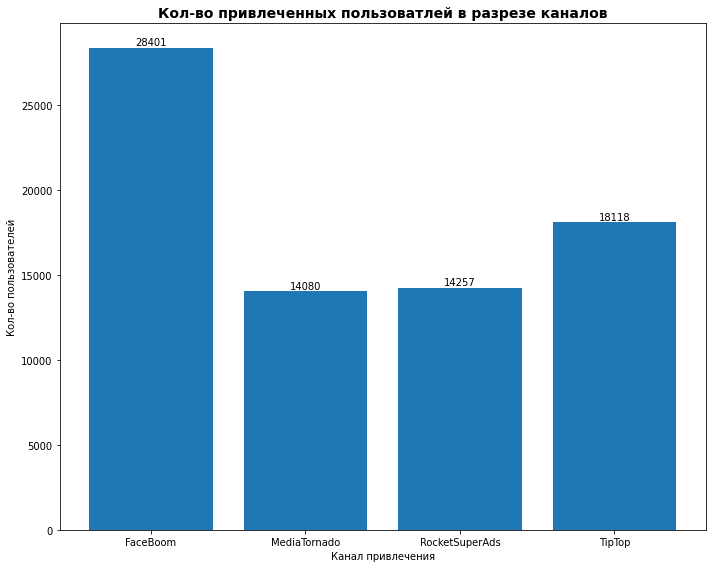

In [32]:
# общее число привлечённых пользователей для каждого источника
channel = df_visits.groupby('first_channel')['user_id'].nunique().reset_index()

plt.figure(figsize = (10, 8))

ax = plt.bar(channel['first_channel'], channel['user_id'])

plt.title('Кол-во привлеченных пользоватлей в разрезе каналов', fontsize = 14, fontweight = 'bold')
plt.xlabel('Канал привлечения')
plt.ylabel('Кол-во пользователей')

for bar in ax:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}', ha = 'center', va = 'bottom')

plt.tight_layout()
plt.show()

Самым «привлекательным» каналом является FaceBoom, он привлек почти вдвое больше пользователей, чем другие каналы (28 400).

На 2 месте TipTop, он дал сервису 18 100 пользователей.

На 3 месте MediaTornado и RocketSuperAds, они привели по ~14 100 пользователей.

In [33]:
# динамика набора новых пользователей по дням в каждом источнике
daily_users = df_visits.groupby(['first_dt', 'first_channel'])['user_id'].nunique().reset_index()

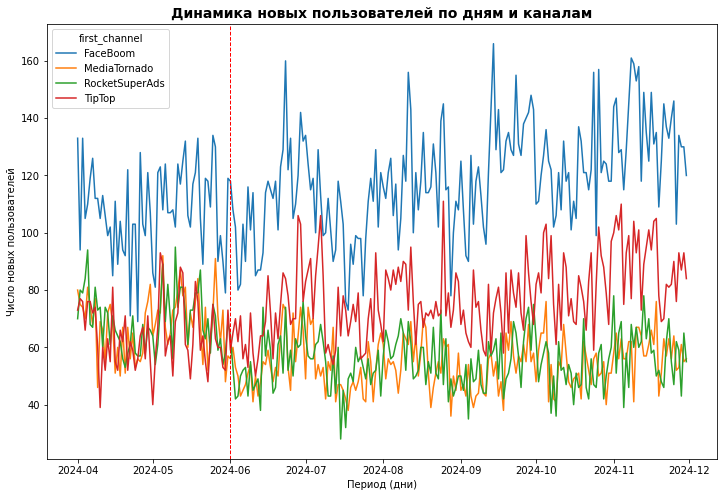

In [34]:
# динамика набора новых пользователей по дням в каждом источнике
plt.figure(figsize=(12, 8))
sns.lineplot(
    data=daily_users,
    x='first_dt',
    y='user_id',
    hue='first_channel' 
)

plt.title('Динамика новых пользователей по дням и каналам', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (дни)')
plt.ylabel('Число новых пользователей')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.show()

Данный график детализирует предыдущий в динамике по дням.

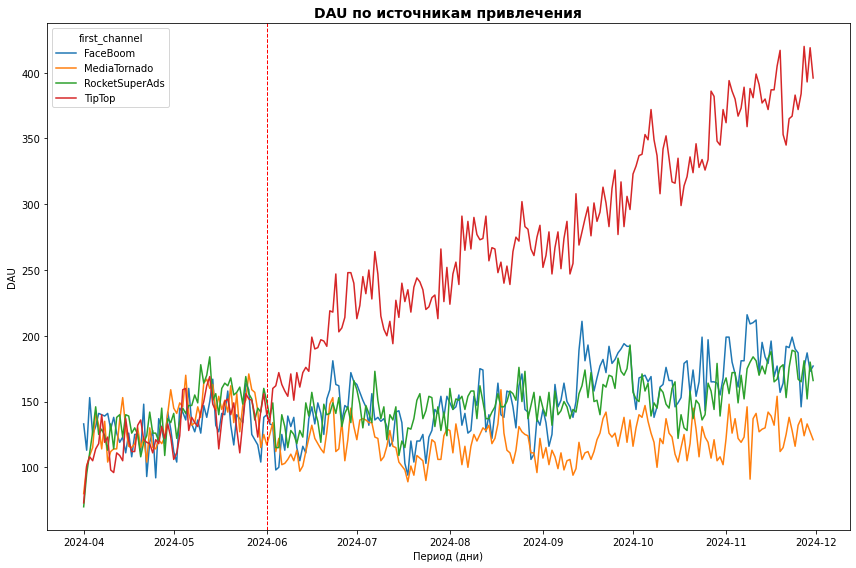

In [35]:
# DAU по источникам привлечения

dau = df_visits.groupby(['session_start', 'first_channel'])['user_id'].nunique(). reset_index()
dau = dau.rename(columns = {'user_id' : 'dau'})

plt.figure(figsize = (12, 8))

sns.lineplot(data = dau,
            x = 'session_start',
            y = 'dau',
            hue = 'first_channel')
plt.title('DAU по источникам привлечения', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (дни)')
plt.ylabel('DAU')


summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.tight_layout()
plt.show()


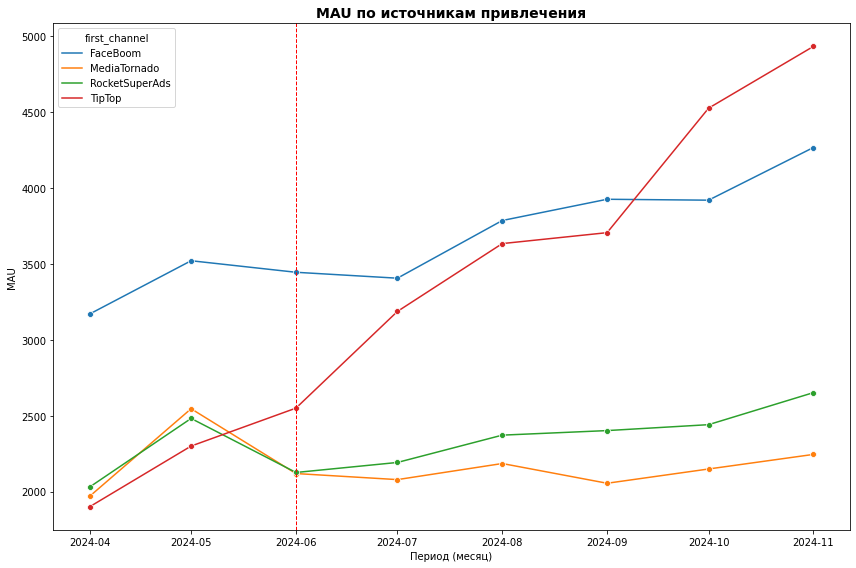

In [36]:
# MAU по источникам привлечения

mau = df_visits
mau['month_activ'] = mau['session_start'].dt.to_period('M').dt.to_timestamp()
mau = mau.groupby(['month_activ', 'first_channel'])['user_id'].nunique().reset_index()
mau = mau.rename(columns = {'user_id': 'mau'})

plt.figure(figsize = (12, 8))

sns.lineplot(data = mau,
            x = 'month_activ',
            y = 'mau',
            hue = 'first_channel',
            marker = 'o') 

plt.title('MAU по источникам привлечения', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (месяц)')
plt.ylabel('MAU')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.tight_layout()

plt.show()

DAU по каналу TipTop сильно выделяется, после появления нового контента, остальные каналы не показывают особенного роста, но и снижения нет.

В дальнейшем анализе стоит присмотреться к TipTop.
MediaTornado тоже показывает небольшой рост

In [37]:
# dau

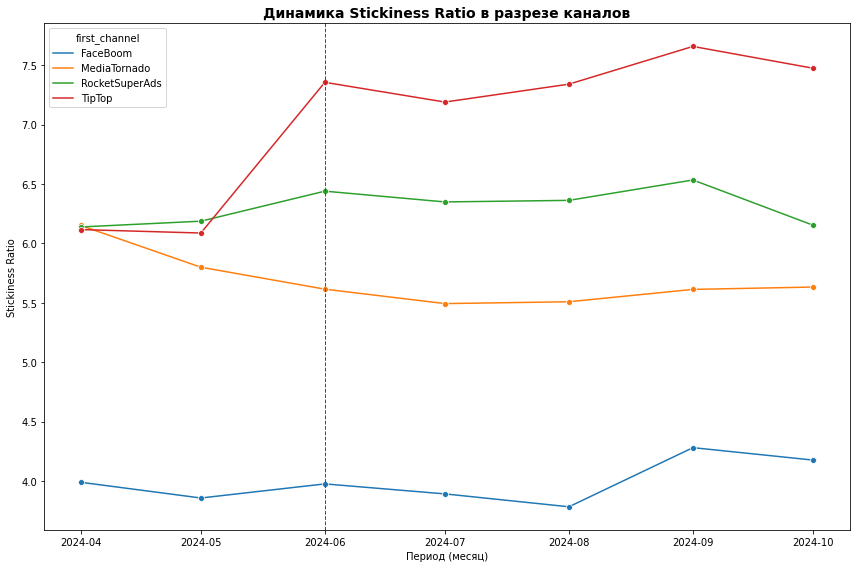

In [38]:
# Stickiness по источникам привлечения
dau['month_activ'] = dau['session_start'].dt.to_period('M').dt.to_timestamp()

dau_mean  = dau.groupby(['month_activ', 'first_channel'])['dau'].mean().reset_index()
dau_mean = dau_mean.rename(columns = {'dau' : 'dau_mean'})

dau_mau = mau.merge(dau_mean, how = 'left', on = ['month_activ', 'first_channel'])
dau_mau['stickiness'] = dau_mau['dau_mean'] / dau_mau['mau'] * 100
dau_mau = dau_mau[dau_mau['month_activ'] < '2024-11-01']

plt.figure(figsize = (12, 8))

sns.lineplot(data = dau_mau,
            x = 'month_activ',
            y = 'stickiness',
            hue = 'first_channel',
            marker = 'o')
plt.title('Динамика Stickiness Ratio в разрезе каналов', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (месяц)')
plt.ylabel('Stickiness Ratio')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.tight_layout()

plt.show()

На данном моменте можно сделать предварительный вывод, что канал TipTop наиболее предпочтительный канал для бизнеса.

Он:

* на 2 месте по привлечению пользователей;
* DAU и MAU у него выше, чем у остальных;
* и коэффициент «липкости» у него вырос, начиная с лета.

Нужно будет посмотреть на другие метрики. Пока этот канал является фаворитом по сравнению с др.

In [39]:
# Скользящее удержание

visits_28d = df_visits[df_visits['n_period'] < 28].copy()

visits_28d['week_cohort'] = visits_28d['first_dt'].dt.to_period('W').dt.to_timestamp()

# размер когорты на 0 день 
visits_28d_first_day = visits_28d[visits_28d['n_period'] == 0].copy()
visits_28d_first_day = visits_28d_first_day.groupby(['first_channel', 'week_cohort'])['user_id'].nunique().reset_index()
visits_28d_first_day = visits_28d_first_day.rename(columns = {'user_id': 'user_1_day'})

# размер когорт на 14 и последующие дни
visits_28d_n_days = visits_28d[visits_28d['n_period'] >= 13].copy()
visits_28d_n_days = visits_28d_n_days.groupby(['first_channel', 'week_cohort'])['user_id'].nunique().reset_index()
visits_28d_n_days = visits_28d_n_days.rename(columns = {'user_id': 'user_n_days'})

# объединение таблиц + убираем ноябрь
rr = visits_28d_first_day.merge(visits_28d_n_days, on = ['first_channel', 'week_cohort'], how = 'left')
rr = rr[rr['week_cohort'] < '2024-11-01' ]

rr['rr'] = rr['user_n_days'] / rr['user_1_day'] * 100
rr

,first_channel,week_cohort,user_1_day,user_n_days,rr
0,FaceBoom,2024-04-01,820,10.0,1.219512
1,FaceBoom,2024-04-08,749,11.0,1.468625
2,FaceBoom,2024-04-15,697,13.0,1.865136
3,FaceBoom,2024-04-22,676,10.0,1.479290
4,FaceBoom,2024-04-29,747,13.0,1.740295
...,...,...,...,...,...
131,TipTop,2024-09-30,602,162.0,26.910299
132,TipTop,2024-10-07,564,173.0,30.673759
133,TipTop,2024-10-14,527,137.0,25.996205
134,TipTop,2024-10-21,577,165.0,28.596187


In [40]:
rr.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 124 entries, 0 to 135
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   first_channel  124 non-null    object        
 1   week_cohort    124 non-null    datetime64[ns]
 2   user_1_day     124 non-null    int64         
 3   user_n_days    124 non-null    float64       
 4   rr             124 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 5.8+ KB


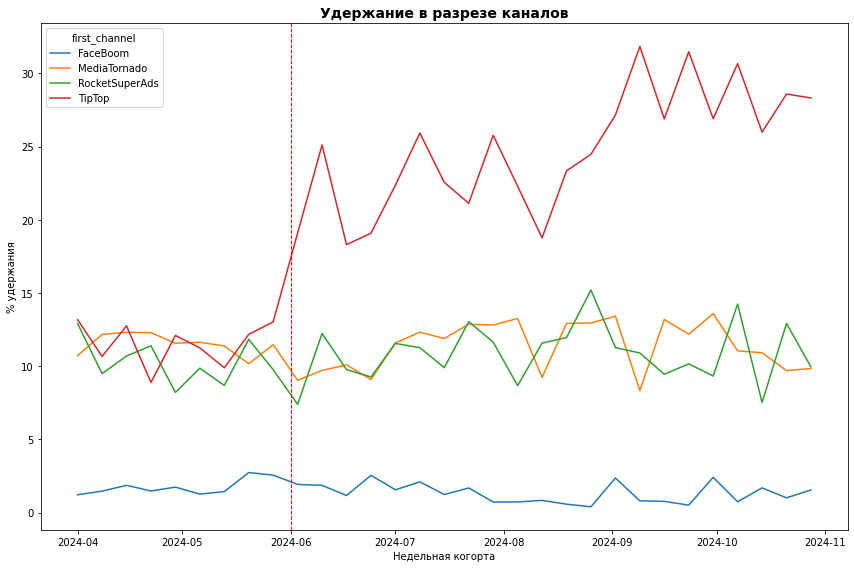

In [41]:
plt.figure(figsize = (12, 8))

sns.lineplot(data = rr,
            x = 'week_cohort',
            y= 'rr',
            hue = 'first_channel')

plt.title('Удержание в разрезе каналов', fontsize = 14, fontweight = 'bold')
plt.xlabel('Недельная когорта')
plt.ylabel('% удержания')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.tight_layout()

plt.show()

Тут также пока сильно выделяется канал TipTop, у него ощутимо вышел % удержания, чем у остальных каналов. С начала лета он единственный вырос, когда другие каналы не отреагировали на изменения

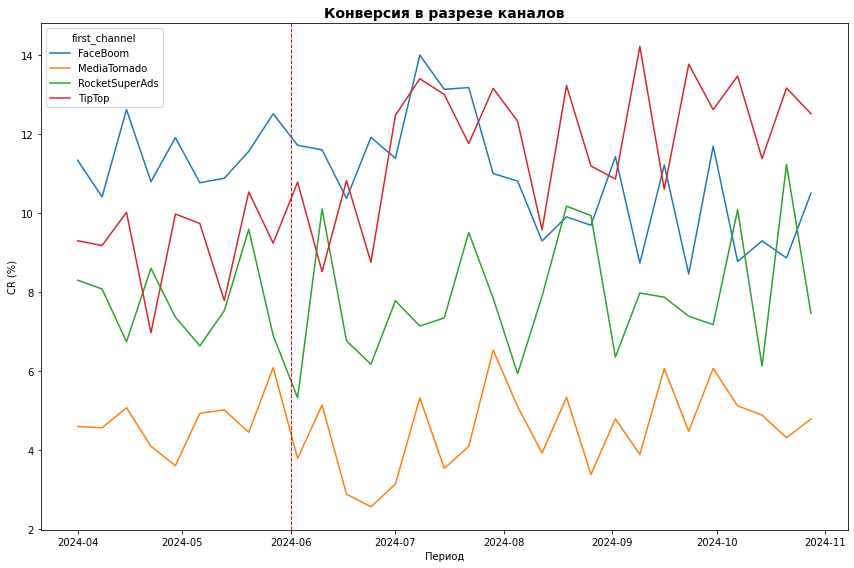

In [42]:
# Конверсия в покупку

df_buyer = df_orders[df_orders['n_period'] < 28]
df_buyer = df_buyer.copy()
df_buyer['cohort_week'] = df_buyer['first_dt'].dt.to_period('W').dt.start_time

buyer = df_buyer.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index()
buyer = buyer.rename(columns = {'user_id' : 'buyer'})

df_user = df_visits[df_visits['n_period'] < 28]
df_user = df_user.copy()
df_user['cohort_week'] = df_user['first_dt'].dt.to_period('W').dt.start_time
user = df_user.groupby(['cohort_week', 'first_channel'])['user_id'].nunique().reset_index()

df_cr = user.merge(buyer, how = 'left', on = ['cohort_week', 'first_channel'])
df_cr['cr'] = df_cr['buyer'] / df_cr['user_id'] * 100
df_cr = df_cr[df_cr['cohort_week'] < '2024-11-01']
# df_cr

plt.figure(figsize = (12, 8))

sns.lineplot(data = df_cr,
            x = 'cohort_week',
            y = 'cr',
            hue = 'first_channel')

plt.title('Конверсия в разрезе каналов', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период')
plt.ylabel('CR (%)')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.tight_layout()
plt.show()

Конверсия у когорт, начиная с 2024-06, по каналу TipTop подросла. 
По FaceBoom тоже конверсия хорошая, хотя видно, что к концу она снижается. 
Другие каналы не показывают изменений после появления нового контента, т. е. их конверсия колеблется в тех же интервалах, что и до изменений.

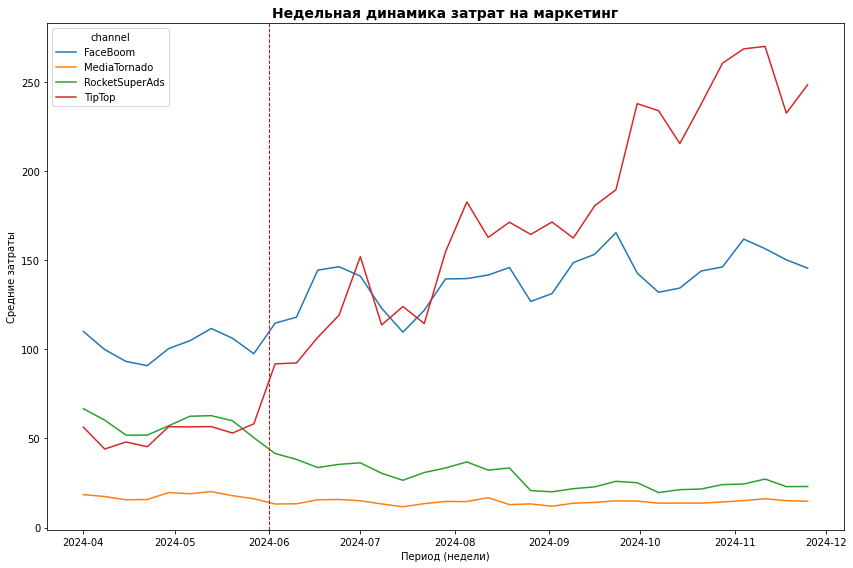

In [43]:
# Недельная динамика затрат на маркетинг по каждому источнику привлечения
df_costs_week = df_costs
df_costs_week['week'] = df_costs_week['dt'].dt.to_period('W').dt.start_time
df_week = df_costs_week.groupby(['week', 'channel'])['costs'].mean().reset_index()


plt.figure(figsize = (12, 8))

sns.lineplot(data = df_week,
            x= 'week',
            y = 'costs',
            hue = 'channel')

plt.title('Недельная динамика затрат на маркетинг', fontsize = 14, fontweight = 'bold')
plt.xlabel('Период (недели)')
plt.ylabel('Средние затраты')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.tight_layout()
plt.show()

У каналов `MediaTornado` и `RocketSuperAds` затраты на маркетинг не растут, а у `MediaTornado` даже чуть-чуть снизились. 

Рост виден у `TipTop`, и рост достаточно существенный, который продолжает расти на протяжении всего анализируемого периода. У `FaceBoom` незначительно подросли и стабилизировались.

In [44]:
profiles.head()
#df_orders.head()

,user_id,first_dt,first_channel,cac,month
0,26034876,2024-05-29,FaceBoom,0.953250,2024-05-01
1,69890364,2024-06-28,RocketSuperAds,0.604917,2024-06-01
2,75610104,2024-06-09,FaceBoom,1.196159,2024-06-01
3,76692397,2024-10-21,FaceBoom,1.147967,2024-10-01
4,80224421,2024-06-21,FaceBoom,1.208981,2024-06-01


In [45]:
# Средний САС по канала
avg_cac = profiles.copy()
avg_cac['week_cohort'] = avg_cac['first_dt'].dt.to_period('W').dt.to_timestamp()
avg_cac = avg_cac.groupby(['week_cohort', 'first_channel']).agg(mean_cac = ('cac', 'mean'),
                                                                 cnt_users = ('user_id', 'nunique')).reset_index()

# Считаем LTV
avg_ltv = df_orders[df_orders['n_period'] < 28].copy()
avg_ltv['week_cohort'] = avg_ltv['first_dt'].dt.to_period('W').dt.to_timestamp()
avg_ltv = avg_ltv.groupby(['week_cohort', 'first_channel'])['revenue'].sum().reset_index()

cac_ltv_roi = avg_ltv.merge(avg_cac,
                           on = ['week_cohort' , 'first_channel'])

cac_ltv_roi['ltv'] = cac_ltv_roi['revenue'] / cac_ltv_roi['cnt_users']

# считаем ROI
cac_ltv_roi['roi'] = (cac_ltv_roi['ltv'] - cac_ltv_roi['mean_cac']) / cac_ltv_roi['mean_cac'] * 100
cac_ltv_roi = cac_ltv_roi[['week_cohort', 'first_channel', 'mean_cac', 'ltv', 'roi']]

cac_ltv_roi = cac_ltv_roi[cac_ltv_roi['week_cohort'] < '2024-11-01']
cac_ltv_roi.head()

,week_cohort,first_channel,mean_cac,ltv,roi
0,2024-04-01,FaceBoom,0.938873,0.463854,-50.594635
1,2024-04-01,MediaTornado,0.247736,0.366724,48.030068
2,2024-04-01,RocketSuperAds,0.860978,1.336402,55.219115
3,2024-04-01,TipTop,0.763545,1.541473,101.883614
4,2024-04-08,FaceBoom,0.933074,0.450013,-51.770905


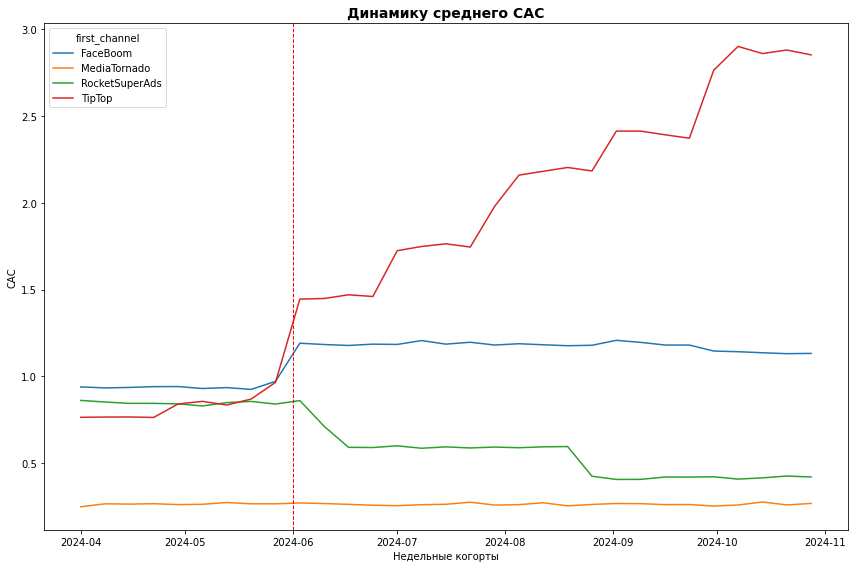

In [46]:
# визуализируем CAC

plt.figure(figsize = (12, 8))

sns.lineplot(data = cac_ltv_roi,
            x = 'week_cohort',
            y = 'mean_cac',
            hue = 'first_channel')

plt.title('Динамику среднего CAC', fontsize = 14, fontweight = 'bold')
plt.xlabel('Недельные когорты')
plt.ylabel('САС')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.tight_layout()

plt.show()

Затраты на `TipTop` растут от когорты к когорте. 

У `FaceBoom` есть скачок, когда были изменения, а далее стабилизация. 

В `RocketSuperAds` идет снижение после начала лета.

У `MediaTornado` затраты стабильны.

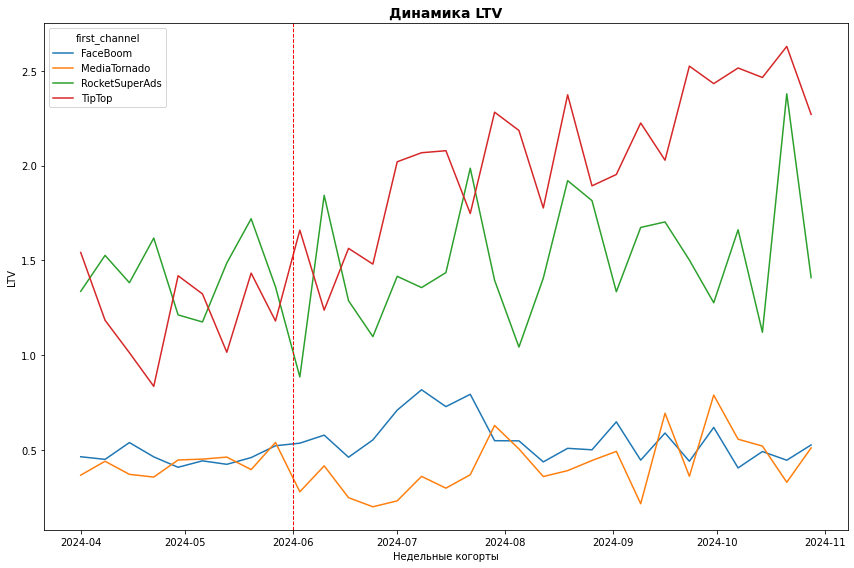

In [47]:
# визуальзация LTV

plt.figure(figsize = (12, 8))

sns.lineplot(data = cac_ltv_roi,
            x = 'week_cohort',
            y = 'ltv',
            hue = 'first_channel')

plt.title('Динамика LTV', fontsize = 14, fontweight = 'bold')
plt.xlabel('Недельные когорты')
plt.ylabel('LTV')

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.tight_layout()

plt.show()

По LTV можно сделать следующие выводы:

* `TipTop`: видна положительная динамика;
* `RocketSuperAds`: сильная волатильность. Тут достаточно трудно уловить положительные или негативные изменения;
* `MediaTornado` и `FaceBoom`: их показатель достаточно стабильный. Видно, что изменения, которые произошли в начале лета, на них не повлияли.

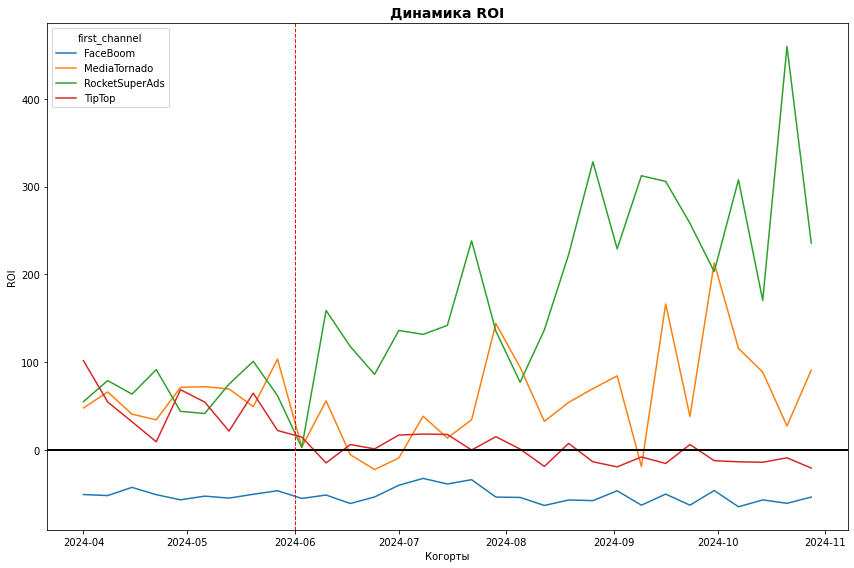

In [48]:
# Визуализация ROI

plt.figure(figsize = (12, 8))

sns.lineplot(data = cac_ltv_roi,
            x = 'week_cohort',
            y = 'roi',
            hue = 'first_channel')

plt.axhline(0,
           color = 'black',
           linestyle = '-',
           linewidth = 2)

summer = pd.to_datetime('2024-06-01')

plt.axvline(summer,
           color = 'red',
           linestyle = '--',
           linewidth = 1)

plt.title('Динамика ROI', fontsize = 14, fontweight = 'bold')
plt.xlabel('Когорты')
plt.ylabel('ROI')

plt.tight_layout()

plt.show()

После оценки ROI можно сделать следующие выводы:

* каналы `TipTop` и `FaceBoom` не окупаются в течение 28 дней;


* У `MediaTornado` и `RocketSuperAds` дела обстоят лучше. Лидером по ROI является канал RocketSuperAds.

1) FaceBoom.

Лидер по кол-ву привлеченных пользователей со средней конверсией, которая имеет тенденцию к снижению. 
Затраты на привлечение у этого канала выше среднего по имеющимся каналам. 
Является аутсайдером по удержанию и залипанию пользователей. 
Также по LTV и ROI.

2) TipTop

Канал приводит достаточное кол-во пользователей (2 место среди всех каналов). 
Через этот канал приходят самые активные клиенты, которые часто пользуются сервисом. 
Канал является лидером по конверсии в покупку. 
Из минусов можно выделить растущие затраты на маркетинг, вследствие чего канал не окупается за 28 дней.

3) MediaTornado и RocketSuperAds

Аутсайдеры по привлечению пользователей. 
Но пользователи, пришедшие через эти каналы, имеют хорошую и стабильную вовлеченность. 
Из минусов можно выделить низкую конверсию по сравнению с др. каналами, но и эти каналы имеют самые низкие затраты на привлечение. 
А у RocketSuperAds даже есть тенденция к снижению затрат. 
Эти каналы различаются по LTV. RocketSuperAds — один из лидеров, когда MediaTornado имеет слабый показатель. 
Но в итоге инвестиции в эти каналы окупаются за 28 дней.

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости, рассчитаем и визуализируем в виде тепловой карты значения ROI за больший период, например за 8–10 недель.

In [49]:
df_orders.head()
#profiles.head()

,user_id,event_dt,revenue,first_dt,first_channel,cac,n_period
0,771951256319,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0
1,829942381059,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0
2,727879856738,2024-04-01,14.99,2024-04-01,FaceBoom,0.939390,0
3,481270888930,2024-04-01,2.99,2024-04-01,TipTop,0.742467,0
4,844695029762,2024-04-01,2.99,2024-04-01,FaceBoom,0.939390,0


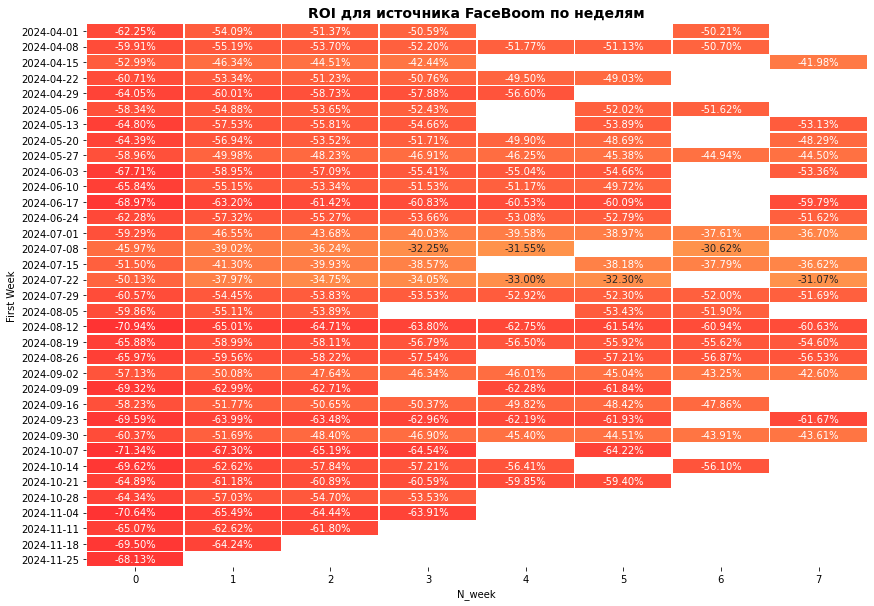

In [50]:
import matplotlib.colors as mlocors

pay_period = df_orders.copy() # берем данные из покупок
pay_period['first_week'] = pay_period['first_dt'].dt.to_period('W').dt.to_timestamp() # выделяем первую неделю привлечения
pay_period['purchase_week'] = pay_period['event_dt'].dt.to_period('W').dt.to_timestamp() # выделяем неделю покупки

pay_period['n_week'] = ((pay_period['purchase_week'] - pay_period['first_week']).dt.days / 7).astype('int16') # разница между неделей покупки и неделей привлечпения
# pay_period['n_week'].unique()

pay_period = pay_period.groupby(['first_channel', 'first_week', 'n_week'])['revenue'].sum().reset_index()
pay_period = pay_period.sort_values(by = ['first_channel', 'n_week'])
pay_period['cum_revenue'] = pay_period.groupby(['first_channel', 'first_week'])['revenue'].cumsum()

cohor_size = profiles.copy()
cohor_size['first_week'] = cohor_size['first_dt'].dt.to_period('W').dt.to_timestamp()
cohor_size = cohor_size.groupby(['first_channel', 'first_week']).agg(cnt_users = ('user_id', 'nunique'),
                                                                    avg_cac = ('cac', 'mean')).reset_index()


pay_period = pay_period.merge(cohor_size,
                             on = ['first_channel', 'first_week'])

pay_period['ltv'] = pay_period['cum_revenue'] / pay_period['cnt_users']
pay_period['roi'] = (pay_period['ltv'] - pay_period['avg_cac']) / pay_period['avg_cac']

# channels = ['FaceBoom', 'TipTop']

cmap = mlocors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N = 100)


tabel = pay_period[(pay_period['first_channel'] == 'FaceBoom') & (pay_period['n_week'] < 8)]
pivot_tabel = tabel.pivot(index = 'first_week',
                             columns = 'n_week',
                             values = 'roi')

pivot_tabel.index = pd.to_datetime(pivot_tabel.index).strftime('%Y-%m-%d')

plt.figure(figsize = (14, 10))
sns.heatmap(data = pivot_tabel,
           annot = True,
           cmap = cmap,
           fmt = '.2%',
           linewidths=0.5, linecolor='white', 
        vmax=1, cbar=False)

plt.title('ROI для источника FaceBoom по неделям', fontsize = 14, fontweight = 'bold')
plt.xlabel('N_week')
plt.ylabel('First Week')

plt.show()

In [51]:
pay_period

,first_channel,first_week,n_week,revenue,cum_revenue,cnt_users,avg_cac,ltv,roi
0,FaceBoom,2024-04-01,0,290.63,290.63,820,0.938873,0.354427,-0.622498
1,FaceBoom,2024-04-01,1,62.81,353.44,820,0.938873,0.431024,-0.540913
2,FaceBoom,2024-04-01,2,20.94,374.38,820,0.938873,0.456561,-0.513714
3,FaceBoom,2024-04-01,3,5.98,380.36,820,0.938873,0.463854,-0.505946
4,FaceBoom,2024-04-01,6,2.99,383.35,820,0.938873,0.467500,-0.502063
...,...,...,...,...,...,...,...,...,...
1973,TipTop,2024-11-11,1,460.67,952.80,657,2.875467,1.450228,-0.495655
1974,TipTop,2024-11-11,2,245.32,1198.12,657,2.875467,1.823623,-0.365800
1975,TipTop,2024-11-18,0,524.97,524.97,567,2.869575,0.925873,-0.677348
1976,TipTop,2024-11-18,1,355.52,880.49,567,2.869575,1.552892,-0.458842


Канал `FaceBoom` с точки зрения ROI крайне невыгоден. Нужно очень продолжительное время, чтобы он окупился.

In [52]:
# tabel.head(15)

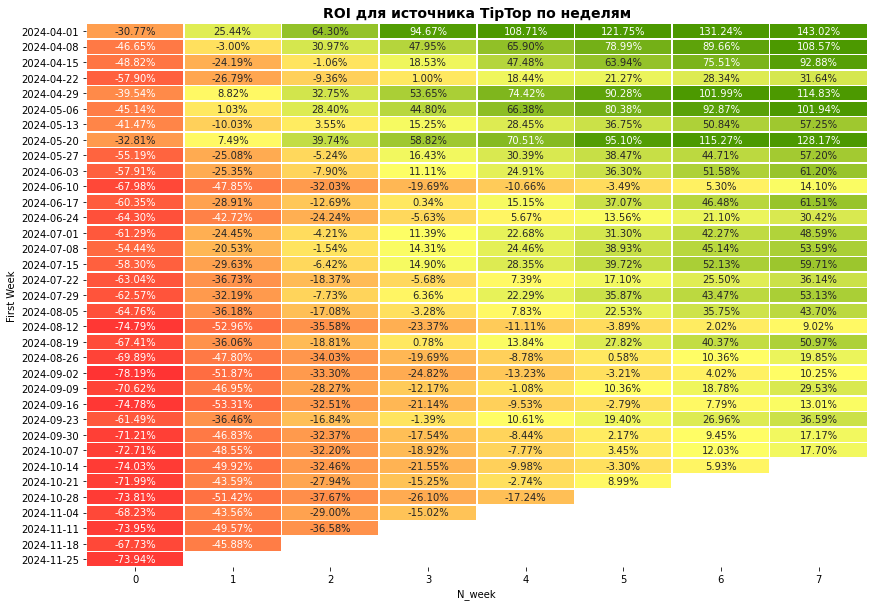

In [53]:
tabel = pay_period[(pay_period['first_channel'] == 'TipTop') & (pay_period['n_week'] < 8)]
pivot_tabel = tabel.pivot(index = 'first_week',
                             columns = 'n_week',
                             values = 'roi')

pivot_tabel.index = pd.to_datetime(pivot_tabel.index).strftime('%Y-%m-%d')
plt.figure(figsize = (14, 10))
sns.heatmap(data = pivot_tabel,
           annot = True,
           cmap = cmap,
           fmt = '.2%',
           linewidths=0.5, linecolor='white', 
        vmax=1, cbar=False)

plt.title('ROI для источника TipTop по неделям', fontsize = 14, fontweight = 'bold')
plt.xlabel('N_week')
plt.ylabel('First Week')

plt.show()

С `TipTop` ситуация лучше. С 5 недели большинство когорт начинает окупаться, а полностью все когорты окупились только на 7 неделе.

Каналы, которые не окупаются на 28 дней (4 недели), - `FaceBoom` и `TipTop`. Если расширить период анализа до 8–10 недель, то можно сделать выводы:

* `FaceBoom` — очень убыточный канал. Нет когорты, которая за такой срок вышла на окупаемость.
* `TipTop`. Все когорты окупаются только к 7-й неделе.


## Выводы и рекомендации

**Этап №1**

Для анализа использовались 3 датасета:

* `df_visits` - информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года;
* `df_orders` - информация о покупках;
* `df_costs` - информация о затратах на маркетинг.

Данные были хорошего качества, без дублей и пропусков. 

**Этап 2**

Для анализа собрали таблицу profiles, которая содержала:

* user_id
* first_dt - дата привлечения пользователя
* first_channel - канал привлечения
* cac - стоимость привлечения пользователя

И этой информацией дополнили датафреймы: `df_orders` и `df_visits`, а далее рассчитали дневной лайфтайм.

**Этап 3**

Анализ месячной динамики основных метрик:

* DAU и MAU. Активность пользователей растет.
* Stickiness ratio тоже увеличивается. 

Новый контент интересен пользователям, они активно пользуются сервисом.
  
  
  
* CAC. Существенно стали расти расходы на маркетинг после появления нового контента. Расходы увеличиваются каждый месяц;
* LTV тоже хорошо подрос. Но если CAC из месяца в месяц растет, то у LTV после скачка есть стабилизация.
* ROI. 2024-06 (период запуска нового контента) резко падает, далее идет резкий скачок и спад. Что сигнализирует о проблемах с окупаемостью инвестиций в привлечение клиентов.

**Этап 4**

Анализ метрик в разрезе источников привлечения.

1. *Привлечение пользователей:* `FaceBoom` больше всего приводит пользователей (28 400), далее `TipTop` (18 100) и меньше всего `MediaTornado` и `RocketSuperAds` (около 14 000 у каждого).

Появление нового контента лучше сказалось на `FaceBoom` и `TipTop`, после 2024-06 видна положительная динамика по привлечению. А на другие каналы особого влияния не оказал.

2. *DAU* и *MAU*. Тут аналогично ситуации с привлечением. Наиболее активны пользователи, пришедшие через `FaceBoom` и `TipTop` (лидер).

3. *Stickiness Ratio*. 
Тут ситуация немного меняется. `TipTop` также опережает всех по вовлеченности пользователей, и виден явный скачок, начиная с 2024-06. Можно сделать вывод, что пользователям из этого канала новый контент приходится по душе.

Далее схожие показатели и динамику показывают `MediaTornado` и `RocketSuperAds`. Они не реагируют на изменения 2024-06.

А пользователи из `FaceBoom` менее всего вовлечены в сервис. Спортивный контент также не повлиял на этот канал.


4. *Удержание*.
Лучше всего задерживаются в сервисе пользователи из `TipTop`, и новый контент явно повлиял на удержание в лучшую сторону. Второе место делят `MediaTornado` и `RocketSuperAds`. Стабильный показатель, без реакции на изменения 2024-06.

`FaceBoom` здесь также числится в отстающих, и разрыв с др. каналами достаточно существенный.


5. *Конверсия в покупку*.
`TipTop` здесь также лидируется, плюс видна положительная динамика после 2024-06. 
`FaceBoom` тоже имеет хороший % конверсии, но под конец он начинает снижаться. 
`RocketSuperAds` имеет среднюю и стабильную конверсию. 
У `MediaTornado` тоже стабильная конверсия, хотя и самая низкая по сравнению с др. каналами.


6. *Недельные затраты на маркетинг*.
У `MediaTornado` и `RocketSuperAds` затраты самые низкие и стабильные. 
У `FaceBoom` (2 место по затратам) есть небольшое увеличение после 2024-06, а далее стабилизация. 
А `TipTop` с каждой неделей требует всё больше затрат.


7. *LTV на 28 день*
`MediaTornado` и `FaceBoom` хоть и стабильны, но отстают по этому показателю. 
`TipTop` также в лидерах и с явной положительной динамикой после 2024-06. 
`RocketSuperAds` чуть уступает TipTop и особо не реагирует на новый контент.


8. *ROI на 28 день*.
Тут ситуация меняется. Наилучшие показатели у `RocketSuperAds` (лидер) и `Media Tornado`. Причем после 2024-06 видна положительная динамика. 
У `TipTop` ROI падает после 2024-06 и не выходит на окупаемость через 28 дней. 

`FaceBoom` сильно отстают от всех остальных.

**Этап 5**

Анализ окупаемости вложений в FaceBoom и TipTop.

* `FaceBoom`. В итоге видим, что этот канал не окупается совсем, даже на протяжении долгого времени.
* `TipTop`. У него ситуация лучше. На окупаемость ему требуется около 7 недель

**Рекомендации:**

* `FaceBoom`. Стоит подумать над тем, чтобы оптимизировать затраты на этот канала. Деньги с этого канала лучше перенаправить на MediaTornado и RocketSuperAds, чтобы увеличить количество привлеченных клиентов и для стимуляции конверсии в покупку.


* `TipTop`. Этот канал рекомендуется оставить, т. к. он дает трафик, который хорошо вовлекается в новый (спортивный) контент. Главная задача для этого канала - снижение затрат, т. к. затраты на этот канал самые большие и они только растут. 
  Так как показатели у него хорошие, то при успешной оптимизации затрат TipTop может стать самым ценным каналом привлечения. 
  
  
* `MediaTornado` и `RocketSuperAds`. Стоит сконцентрироваться на привлечении большего количества новых пользователей и улучшении конверсии в покупку.